In [1]:
import random
import torch
import matplotlib.pyplot as plt
from datasets import load_from_disk
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
    
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "nanoVLM"))

from nanoVLM.models.vision_language_model import VisionLanguageModel
from model_utils import load_vlm_model

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.7.1+cu118).
W0507 21:37:28.193000 10768 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
BASE_MODEL_ID = "lusxvr/nanoVLM-222M"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sft_model, tokenizer, image_processor = load_vlm_model(
    BASE_MODEL_ID, PROJECT_ROOT / "checkpoints/sft_adapter", DEVICE, is_trainable=False
)

grpo_model, _, _ = load_vlm_model(
    sft_model, PROJECT_ROOT / "checkpoints/grpo_adapter", DEVICE, is_trainable=False
)

C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\peft\tuners\tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
dataset_path = PROJECT_ROOT / "dataset"

ds = load_from_disk(dataset_path)

print("Размер датасета:", len(ds))

Размер датасета: 5280


In [4]:
def predict_action(image, prompt, model, max_new_tokens=1):
    text = f"User: <image>\n{prompt}\nAssistant: "
    
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"]

    image_inputs = image_processor(
        image, 
        return_tensors="pt", 
        do_resize=True, 
        size={"height": 224, "width": 224},
    )
    pixel_values = image_inputs.pixel_values.to(torch.float32).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids, 
            pixel_values, 
            max_new_tokens=max_new_tokens
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

    raw_output = generated_text.lower()
    if "left" in raw_output:
        return "left", generated_text
    elif "right" in raw_output:
        return "right", generated_text
    elif "forward" in raw_output:
        return "forward", generated_text
    
    return None, generated_text

In [5]:
def show_preds(model):
    rng = random.Random(10)
    
    indices = rng.sample(range(len(ds)), 10)

    correct = 0

    for i, idx in enumerate(indices):
        item = ds[idx]

        image = item["ego_image"].convert("RGB")
        prompt = item["prompt"]
        true_action = item["action"]

        pred_action, raw_output = predict_action(image, prompt, model)

        print(f"\n=== Пример {i+1} ===")
        plt.imshow(image)
        plt.axis("off")
        plt.show()

        print("True action:", true_action)
        print("Predicted:", pred_action)
        print("Raw output:", raw_output)

        if pred_action == true_action:
            correct += 1

    print("\n======================")
    print(f"Accuracy: {correct}/10 = {correct/10:.2f}")


=== Пример 1 ===


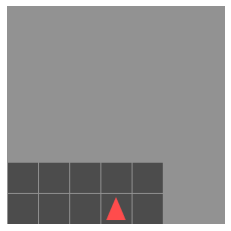

True action: left
Predicted: left
Raw output: left

=== Пример 2 ===


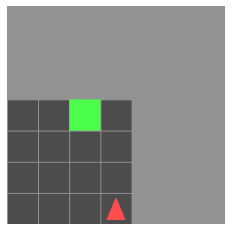

True action: forward
Predicted: forward
Raw output: forward

=== Пример 3 ===


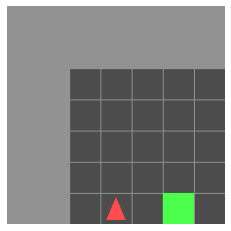

True action: right
Predicted: left
Raw output: Left

=== Пример 4 ===


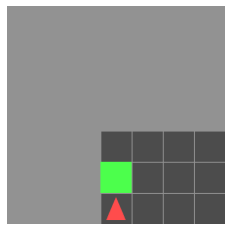

True action: forward
Predicted: forward
Raw output: Forward

=== Пример 5 ===


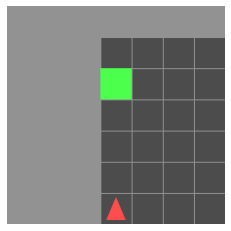

True action: forward
Predicted: forward
Raw output: forward

=== Пример 6 ===


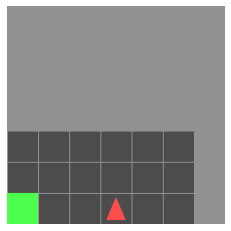

True action: left
Predicted: right
Raw output: right

=== Пример 7 ===


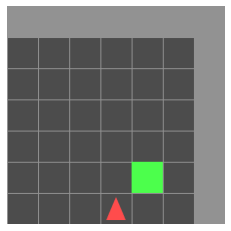

True action: forward
Predicted: forward
Raw output: Forward

=== Пример 8 ===


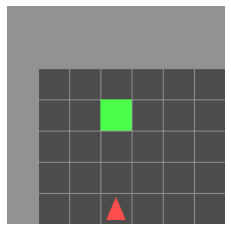

True action: forward
Predicted: forward
Raw output: forward

=== Пример 9 ===


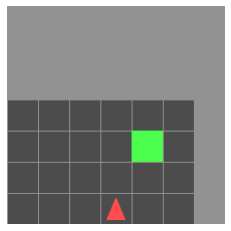

True action: forward
Predicted: forward
Raw output: Forward

=== Пример 10 ===


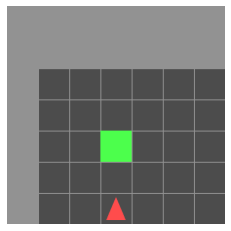

True action: forward
Predicted: forward
Raw output: Forward

Accuracy: 8/10 = 0.80


In [6]:
show_preds(sft_model)


=== Пример 1 ===


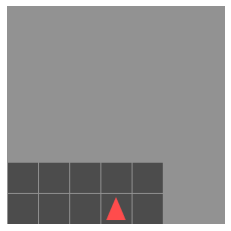

True action: left
Predicted: left
Raw output: left

=== Пример 2 ===


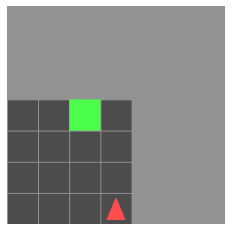

True action: forward
Predicted: forward
Raw output: forward

=== Пример 3 ===


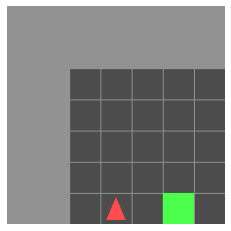

True action: right
Predicted: right
Raw output: Right

=== Пример 4 ===


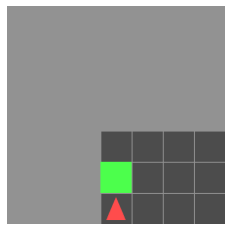

True action: forward
Predicted: forward
Raw output: Forward

=== Пример 5 ===


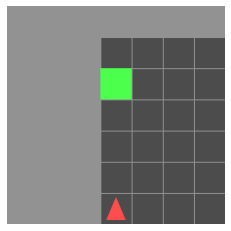

True action: forward
Predicted: forward
Raw output: Forward

=== Пример 6 ===


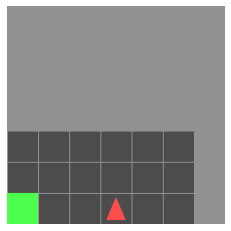

True action: left
Predicted: right
Raw output: right

=== Пример 7 ===


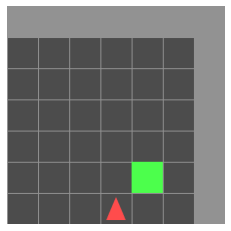

True action: forward
Predicted: forward
Raw output: Forward

=== Пример 8 ===


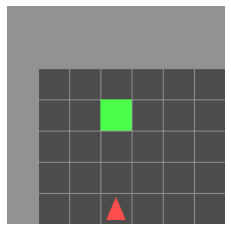

True action: forward
Predicted: forward
Raw output: forward

=== Пример 9 ===


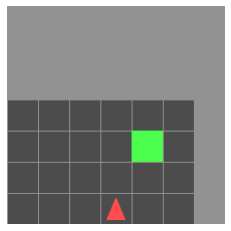

True action: forward
Predicted: forward
Raw output: forward

=== Пример 10 ===


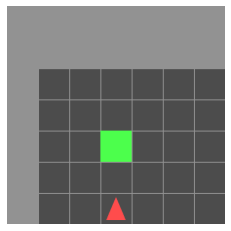

True action: forward
Predicted: forward
Raw output: forward

Accuracy: 9/10 = 0.90


In [7]:
show_preds(grpo_model)